In [ ]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/MER_Multimodal_Fusion

Mounted at /content/drive
/content/drive/MyDrive/MER_Multimodal_Fusion


In [ ]:
%%bash
for condition in audio_only lyrics_only feature model decision cross_modal; do
    python scripts/train.py --config configs/$condition.yaml
done

Training condition: audio_only on cuda
Song Split 
Train: 424 
 Val: 91 
 Test: 91
0.5s Window Split 
Train: 20279 
 Val: 4037 
 Test: 4184
[audio_only] Epoch 001 Train Loss: 0.5688 Val CCC V: 0.0919Val CCC A: 0.0780Val CCC Avg: 0.0849
  -> New best checkpoint saved (val CCC avg: 0.0849)
[audio_only] Epoch 002 Train Loss: 0.4002 Val CCC V: 0.1244Val CCC A: 0.1271Val CCC Avg: 0.1258
  -> New best checkpoint saved (val CCC avg: 0.1258)
[audio_only] Epoch 003 Train Loss: 0.3660 Val CCC V: 0.1348Val CCC A: 0.1350Val CCC Avg: 0.1349
  -> New best checkpoint saved (val CCC avg: 0.1349)
[audio_only] Epoch 004 Train Loss: 0.3565 Val CCC V: 0.1494Val CCC A: 0.1617Val CCC Avg: 0.1555
  -> New best checkpoint saved (val CCC avg: 0.1555)
[audio_only] Epoch 005 Train Loss: 0.3433 Val CCC V: 0.1657Val CCC A: 0.1825Val CCC Avg: 0.1741
  -> New best checkpoint saved (val CCC avg: 0.1741)
[audio_only] Epoch 006 Train Loss: 0.3306 Val CCC V: 0.1659Val CCC A: 0.1856Val CCC Avg: 0.1758
  -> New best check

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 2680.22it/s, Materializing param=encoder.layer.11.output.dense.weight]
RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading weights: 100%|██████████| 197/197 [00:00<00:00, 2361.35it/s, Materializing param=encoder.laye

In [ ]:
%%bash
for condition in audio_only lyrics_only feature model decision cross_modal; do
    python scripts/evaluate.py --config configs/$condition.yaml
done

Evaluating condition: audio_only on cuda
Song Split 
Train: 424 
 Val: 91 
 Test: 91
0.5s Window Split 
Train: 20279 
 Val: 4037 
 Test: 4184
Loaded checkpoint: logs/checkpoints/audio_only_best.pt

--- Test Results: audio_only ---
CCC Valence: 0.2573
CCC Arousal: 0.2094
PCC Valence: 0.3984
PCC Arousal: 0.2899
Test Loss:   0.8921
Evaluating condition: lyrics_only on cuda
Song Split 
Train: 424 
 Val: 91 
 Test: 91
0.5s Window Split 
Train: 20279 
 Val: 4037 
 Test: 4184
Loaded checkpoint: logs/checkpoints/lyrics_only_best.pt

--- Test Results: lyrics_only ---
CCC Valence: 0.2850
CCC Arousal: 0.1805
PCC Valence: 0.3140
PCC Arousal: 0.2047
Test Loss:   0.9091
Evaluating condition: feature on cuda
Song Split 
Train: 424 
 Val: 91 
 Test: 91
0.5s Window Split 
Train: 20279 
 Val: 4037 
 Test: 4184
Loaded checkpoint: logs/checkpoints/feature_best.pt

--- Test Results: feature ---
CCC Valence: 0.2659
CCC Arousal: 0.1804
PCC Valence: 0.3120
PCC Arousal: 0.2124
Test Loss:   0.8917
Evaluating co

A new version of the following files was downloaded from https://huggingface.co/m-a-p/MERT-v1-95M:
- configuration_MERT.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/m-a-p/MERT-v1-95M:
- modeling_MERT.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
Loading weights: 100%|██████████| 197/197 [00:00<00:00, 2605.40it/s, Materializing param=encoder.layer.11.output.dense.weight]
RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 


In [1]:
# Cell 1: Data
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150

results = {
    "Model": [
        "Audio-Only",
        "Lyrics-Only",
        "Feature-Level Fusion",
        "Chen et al.'s Feature-Level AKA Concat-Fusion",
        "Model-Level Fusion",
        "Decision-Level Fusion",
        "Cross-Modal Fusion",
        "Chen et al.'s Cross-Modal AKA RoBERTa-Fusion"
    ],
    "CCC Valence":  [0.2573, 0.2850, 0.2659, 0.0900, 0.3299, 0.2978, 0.1471, 0.1500],
    "CCC Arousal":  [0.2094, 0.1805, 0.1804, 0.1900, 0.2066, 0.2341, 0.0863, 0.1200],
    "PCC Valence":  [0.3984, 0.3140, 0.3120, 0.1200, 0.3760, 0.3415, 0.4099, 0.2300],
    "PCC Arousal":  [0.2899, 0.2047, 0.2124, 0.2300, 0.2358, 0.2759, 0.2719, 0.1700],
}

df = pd.DataFrame(results)

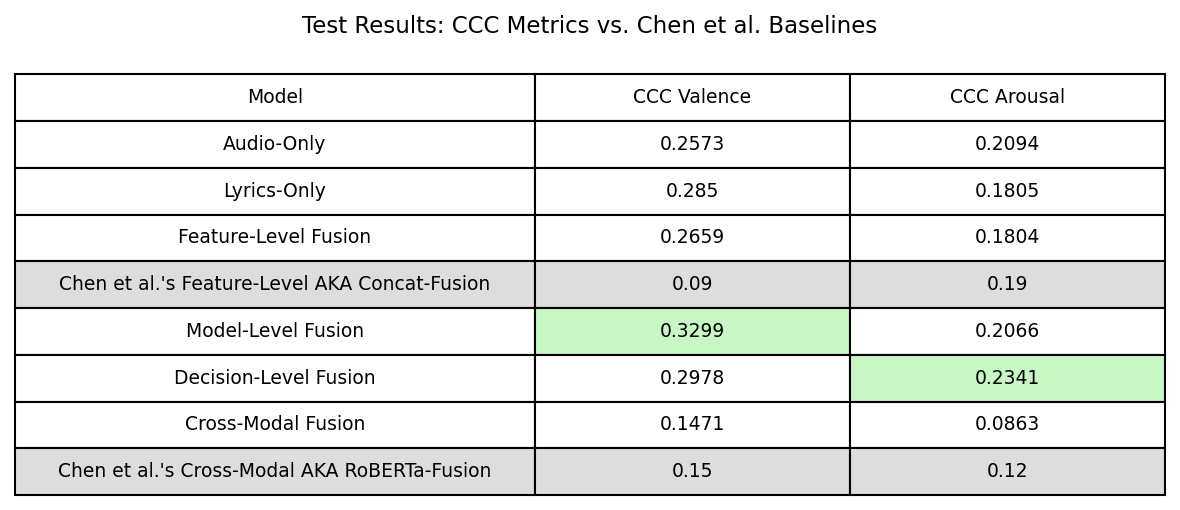

In [6]:
# Cell 2: Results table
df_ccc = df[["Model", "CCC Valence", "CCC Arousal"]]
fig, ax = plt.subplots(figsize=(8, 3.5), dpi=150)
ax.axis("off")
table = ax.table(
    cellText=df_ccc.values,
    colLabels=df_ccc.columns,
    cellLoc="center",
    loc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.8)
table.auto_set_column_width(col=[0])

for col in range(len(df_ccc.columns)):
    table[4, col].set_facecolor("#dddddd")  # Concat-Fusion baseline
    table[8, col].set_facecolor("#dddddd")  # RoBERTa-Fusion baseline

our_models = df_ccc[~df_ccc['Model'].str.startswith("Chen et al.")]
for col_idx, col in enumerate(["CCC Valence", "CCC Arousal"]):
    best_row = our_models[col].idxmax() + 1
    table[best_row, col_idx + 1].set_facecolor("#c8f7c5")

plt.title("Test Results: CCC Metrics vs. Chen et al. Baselines", fontsize=11, pad=20)
plt.tight_layout()
plt.show()

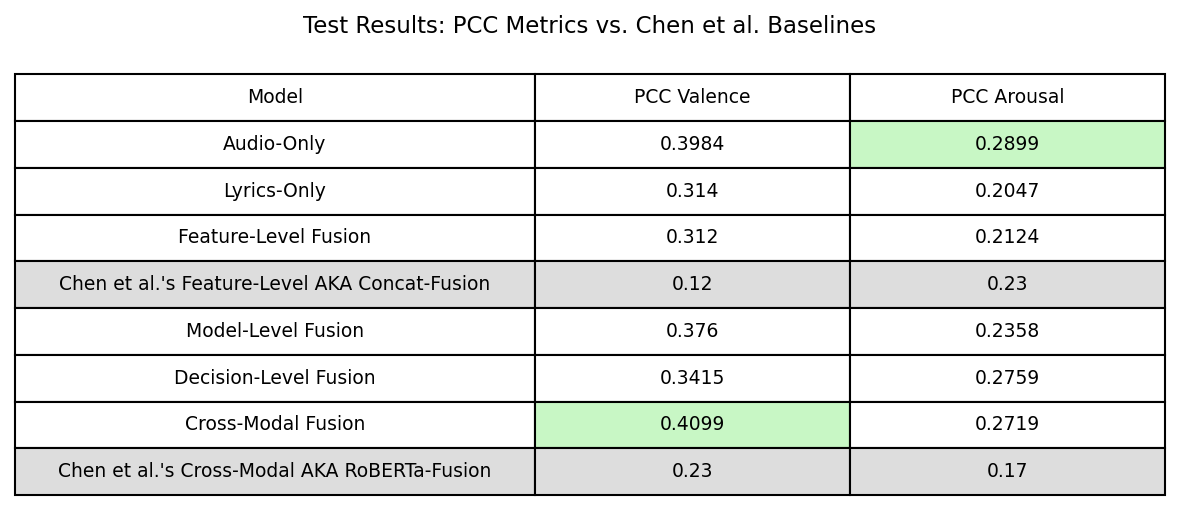

In [8]:
# Cell 2 Part 2: PCC Results table
import matplotlib.pyplot as plt

# Select only the Model column and the PCC metrics
df_pcc = df[["Model", "PCC Valence", "PCC Arousal"]]

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.axis("off")
table = ax.table(
    cellText=df_pcc.values,
    colLabels=df_pcc.columns,
    cellLoc="center",
    loc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.8)
table.auto_set_column_width(col=[0])


# Highlight both baseline rows in light grey (Row 4 and Row 8 including header)
for col in range(len(df_pcc.columns)):
    table[4, col].set_facecolor("#dddddd")  # Concat-Fusion baseline
    table[8, col].set_facecolor("#dddddd")  # RoBERTa-Fusion baseline

# Highlight best result per column in light green (our models only)
our_models = df_pcc[~df_pcc['Model'].str.startswith("Chen et al.")]
for col_idx, col in enumerate(["PCC Valence", "PCC Arousal"]):
    best_row = our_models[col].idxmax() + 1  # +1 for header offset
    table[best_row, col_idx + 1].set_facecolor("#c8f7c5")

plt.title("Test Results: PCC Metrics vs. Chen et al. Baselines", fontsize=11, pad=20)
plt.tight_layout()
plt.show()

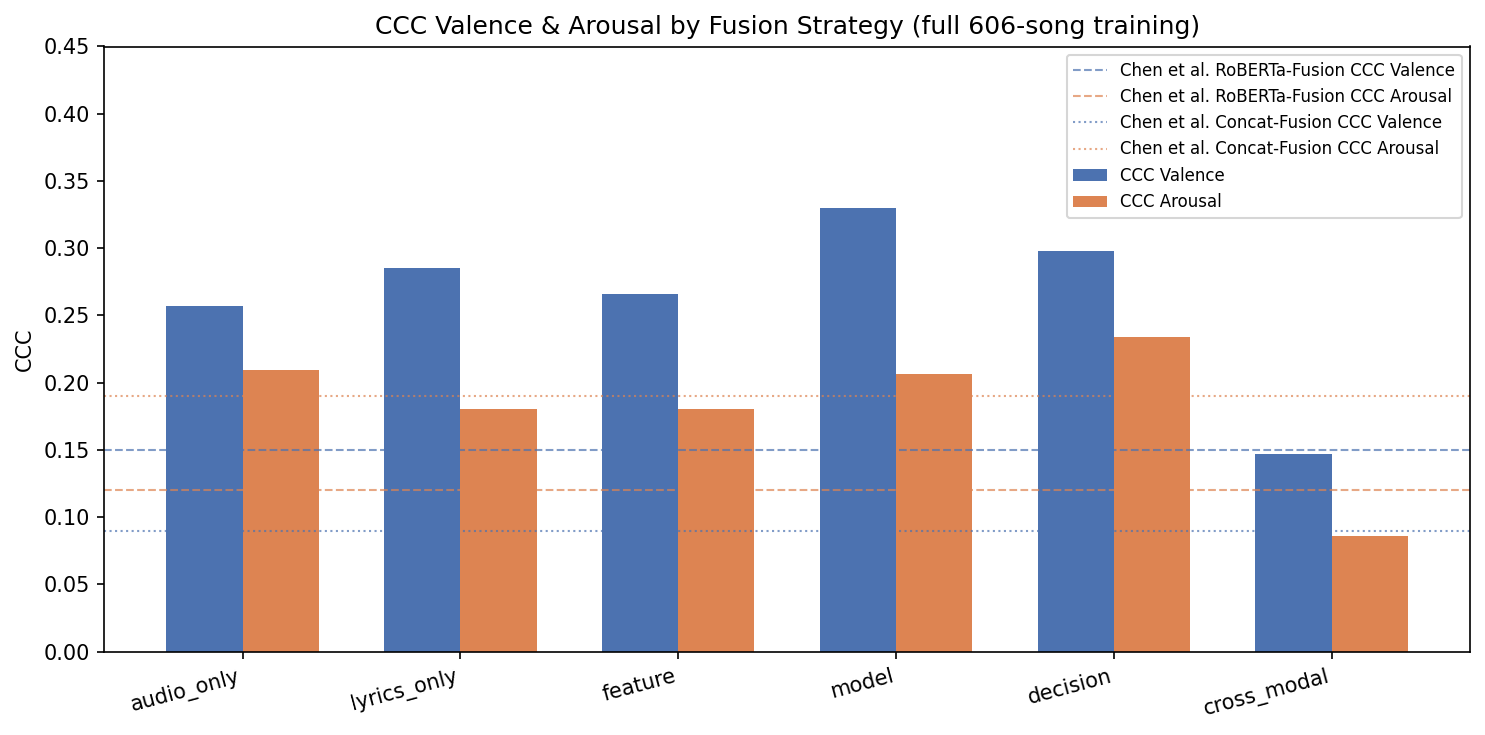

In [ ]:
# Cell 3: Bar chart
conditions = ["audio_only", "lyrics_only", "feature", "model", "decision", "cross_modal"]
ccc_valence = [0.2573, 0.2850, 0.2659, 0.3299, 0.2978, 0.1471]
ccc_arousal = [0.2094, 0.1805, 0.1804, 0.2066, 0.2341, 0.0863]

x = range(len(conditions))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar([i - width/2 for i in x], ccc_valence, width, label="CCC Valence", color="#4C72B0")
bars2 = ax.bar([i + width/2 for i in x], ccc_arousal, width, label="CCC Arousal", color="#DD8452")

# Chen et al. RoBERTa-Fusion baseline
ax.axhline(y=0.15, color="#4C72B0", linestyle="--", linewidth=1, alpha=0.7, label="Chen et al. RoBERTa-Fusion CCC Valence")
ax.axhline(y=0.12, color="#DD8452", linestyle="--", linewidth=1, alpha=0.7, label="Chen et al. RoBERTa-Fusion CCC Arousal")

# Chen et al. Concat-Fusion baseline
ax.axhline(y=0.09, color="#4C72B0", linestyle=":", linewidth=1, alpha=0.7, label="Chen et al. Concat-Fusion CCC Valence")
ax.axhline(y=0.19, color="#DD8452", linestyle=":", linewidth=1, alpha=0.7, label="Chen et al. Concat-Fusion CCC Arousal")

ax.set_xticks(list(x))
ax.set_xticklabels(conditions, rotation=15, ha="right")
ax.set_ylabel("CCC")
ax.set_title("CCC Valence & Arousal by Fusion Strategy (full 606-song training)")
ax.legend(fontsize=8)
ax.set_ylim(0, 0.45)
plt.tight_layout()
plt.show()

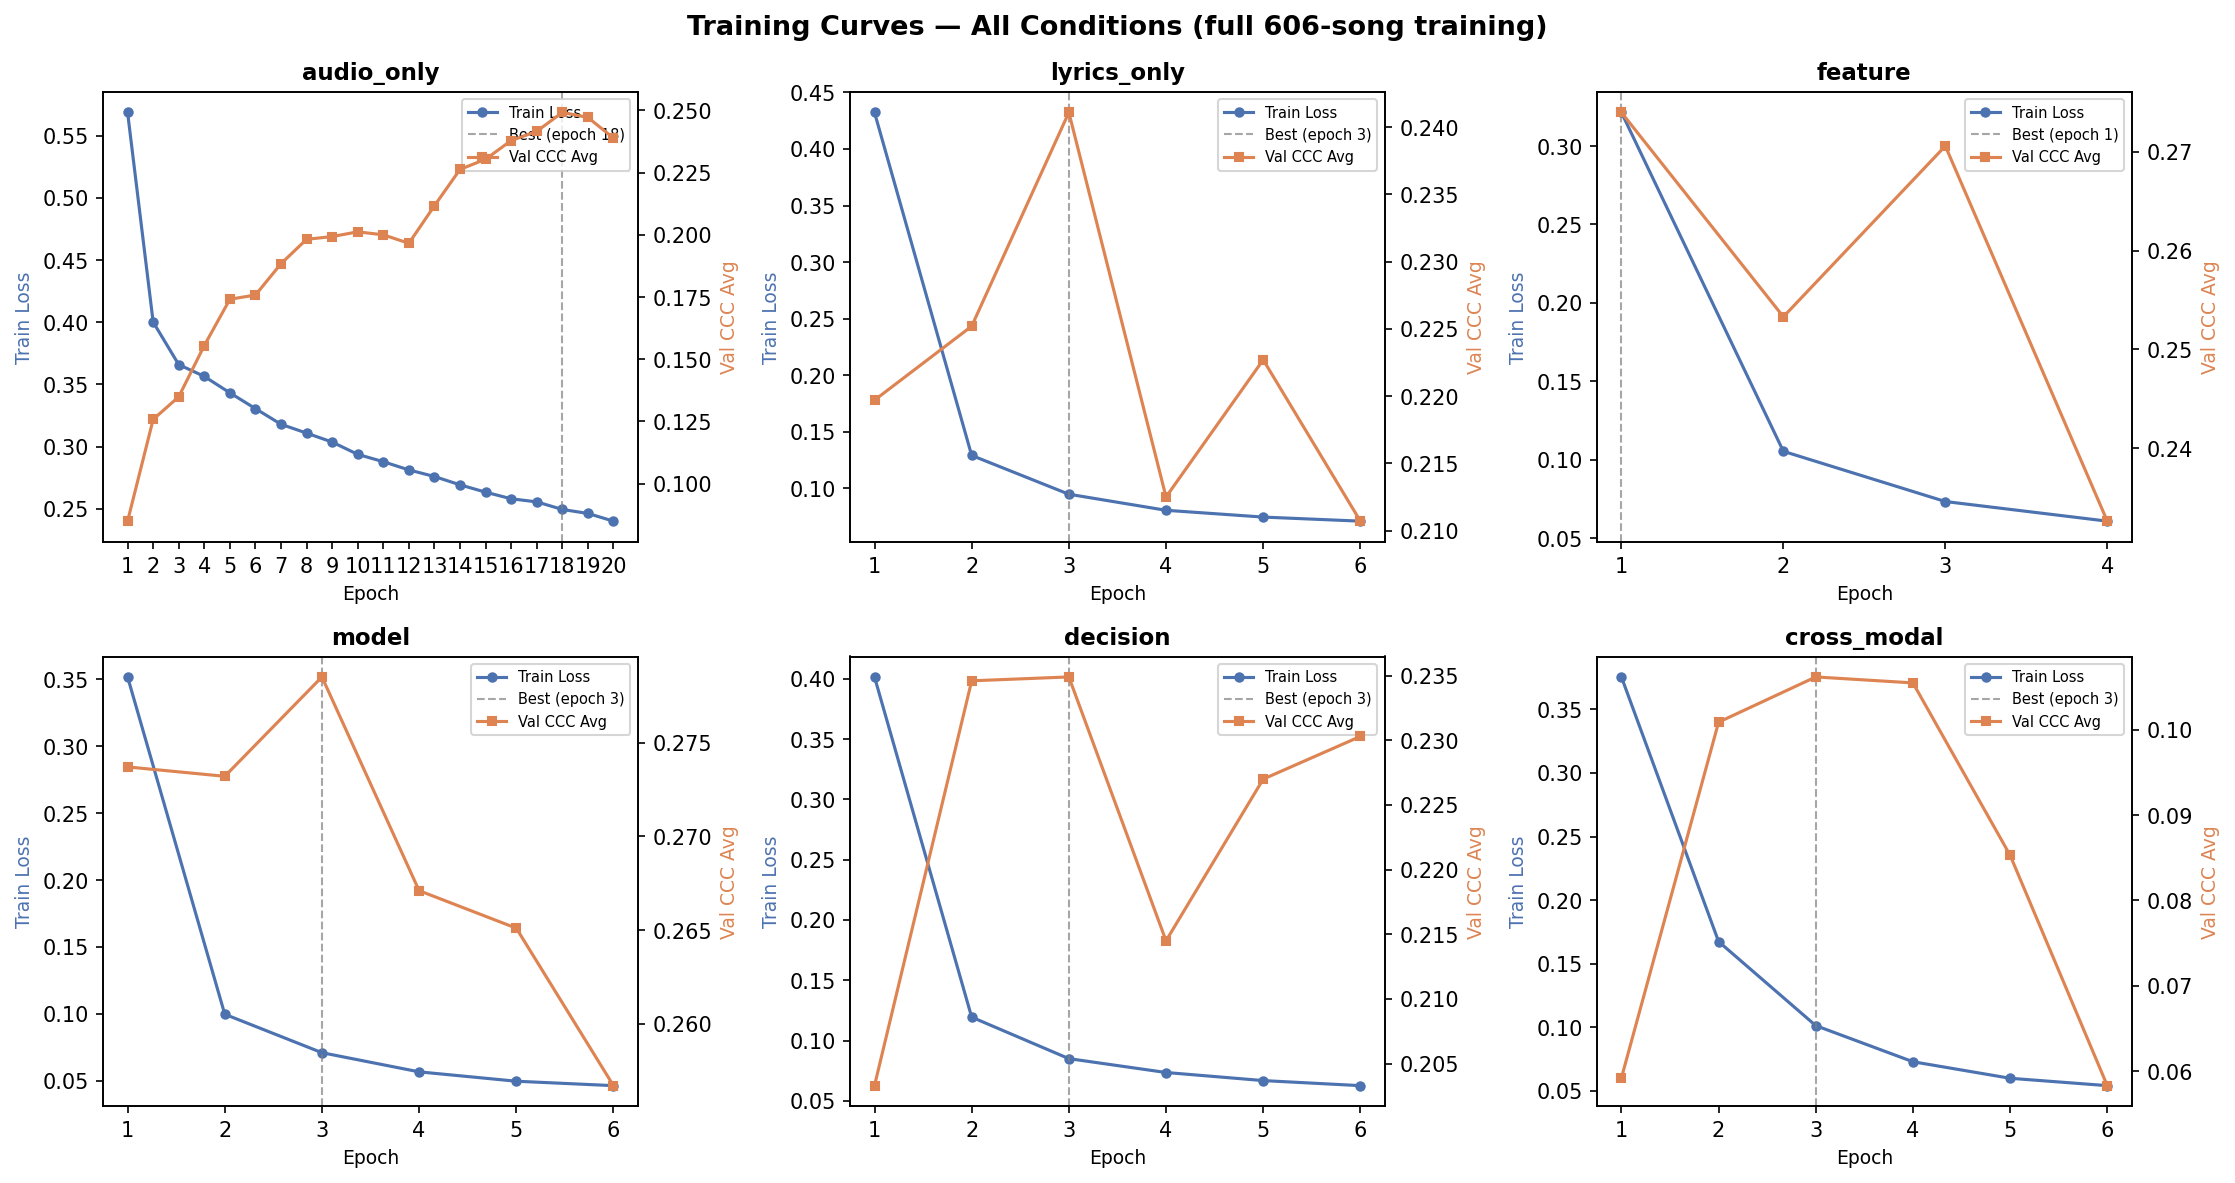

In [ ]:
# Cell 4: Training curves for all 6 conditions
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['figure.dpi'] = 150

# Hardcoded from training logs
training_data = {
    "audio_only": {
        "train_loss": [0.5688,0.4002,0.3660,0.3565,0.3433,0.3306,0.3180,0.3109,0.3037,0.2938,0.2879,0.2813,0.2760,0.2693,0.2634,0.2581,0.2556,0.2495,0.2463,0.2401],
        "val_ccc":   [0.0849,0.1258,0.1349,0.1555,0.1741,0.1758,0.1884,0.1982,0.1993,0.2012,0.2000,0.1966,0.2117,0.2263,0.2304,0.2379,0.2416,0.2492,0.2472,0.2389],
        "best_epoch": 18,
    },
    "lyrics_only": {
        "train_loss": [0.4323,0.1291,0.0948,0.0806,0.0746,0.0710],
        "val_ccc":    [0.2197,0.2252,0.2411,0.2125,0.2227,0.2107],
        "best_epoch": 3,
    },
    "feature": {
        "train_loss": [0.3214,0.1054,0.0734,0.0609],
        "val_ccc":    [0.2740,0.2533,0.2706,0.2326],
        "best_epoch": 1,
    },
    "model": {
        "train_loss": [0.3516,0.0998,0.0711,0.0568,0.0498,0.0465],
        "val_ccc":    [0.2737,0.2732,0.2785,0.2671,0.2651,0.2567],
        "best_epoch": 3,
    },
    "decision": {
        "train_loss": [0.4015,0.1194,0.0850,0.0735,0.0668,0.0626],
        "val_ccc":    [0.2033,0.2346,0.2349,0.2145,0.2270,0.2303],
        "best_epoch": 3,
    },
    "cross_modal": {
        "train_loss": [0.3755,0.1674,0.1013,0.0729,0.0599,0.0541],
        "val_ccc":    [0.0592,0.1009,0.1062,0.1055,0.0853,0.0583],
        "best_epoch": 3,
    },
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (condition, data) in enumerate(training_data.items()):
    ax1 = axes[i]
    ax2 = ax1.twinx()
    epochs = list(range(1, len(data["train_loss"]) + 1))

    ax1.plot(epochs, data["train_loss"], color="#4C72B0", marker="o", markersize=4, label="Train Loss")
    ax2.plot(epochs, data["val_ccc"],    color="#DD8452", marker="s", markersize=4, label="Val CCC Avg")
    ax1.axvline(x=data["best_epoch"], color="gray", linestyle="--", linewidth=1, alpha=0.7,
                label=f"Best (epoch {data['best_epoch']})")

    ax1.set_title(condition, fontsize=11, fontweight="bold")
    ax1.set_xlabel("Epoch", fontsize=9)
    ax1.set_ylabel("Train Loss", color="#4C72B0", fontsize=9)
    ax2.set_ylabel("Val CCC Avg", color="#DD8452", fontsize=9)
    ax1.set_xticks(epochs)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=7, loc="upper right")

plt.suptitle("Training Curves — All Conditions (full 606-song training)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()